# Первая часть. Исследование

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

## Загрузка данных 

In [3]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 77.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 71.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 27.3MB/s]


In [4]:
data = pd.read_csv('./train.csv')

In [5]:


# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [6]:


# Загрузка данных
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')

# Первые 5 строк данных
print("Train Data Sample:")
display(train.sample(5))

# Проверка на пропуски
print("\nMissing Values in Train Data:")
print(train.isna().sum())

# for i in train.columns:
#   print(type(train[i]))

Train Data Sample:


,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
3382,43,77.85,3365.85,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,1
4390,31,89.45,2807.65,Male,1,Yes,No,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,No,Month-to-month,No,Electronic check,0
240,25,20.95,495.15,Male,0,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Bank transfer (automatic),0
3395,70,105.55,7195.35,Female,1,Yes,No,Yes,Yes,Fiber optic,No,Yes,No,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),0
1639,48,99.00,4744.35,Male,1,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,One year,Yes,Electronic check,0



Missing Values in Train Data:
ClientPeriod                0
MonthlySpending             0
TotalSpent                  0
Sex                         0
IsSeniorCitizen             0
HasPartner                  0
HasChild                    0
HasPhoneService             0
HasMultiplePhoneNumbers     0
HasInternetService          0
HasOnlineSecurityService    0
HasOnlineBackup             0
HasDeviceProtection         0
HasTechSupportAccess        0
HasOnlineTV                 0
HasMovieSubscription        0
HasContractPhone            0
IsBillingPaperless          0
PaymentMethod               0
Churn                       0
dtype: int64


In [7]:
## Обработка данных
# Заполнение пропусков в TotalSpent
train['TotalSpent'] = pd.to_numeric(train['TotalSpent'], errors='coerce')
train['TotalSpent'].fillna(train['TotalSpent'].median(), inplace=True)
test['TotalSpent'] = pd.to_numeric(test['TotalSpent'], errors='coerce')
test['TotalSpent'].fillna(test['TotalSpent'].median(), inplace=True)


<ipython-input-7-49a2f49b6ea1>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['TotalSpent'].fillna(train['TotalSpent'].median(), inplace=True)
<ipython-input-7-49a2f49b6ea1>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

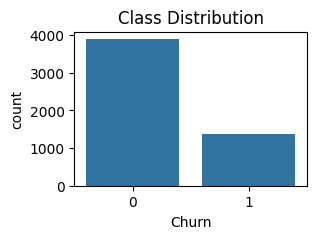

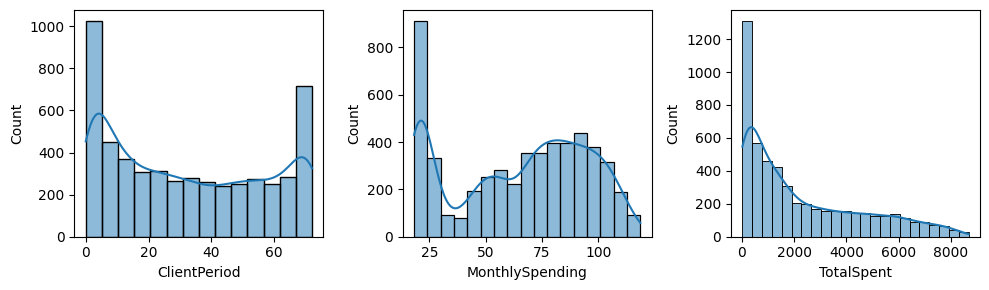

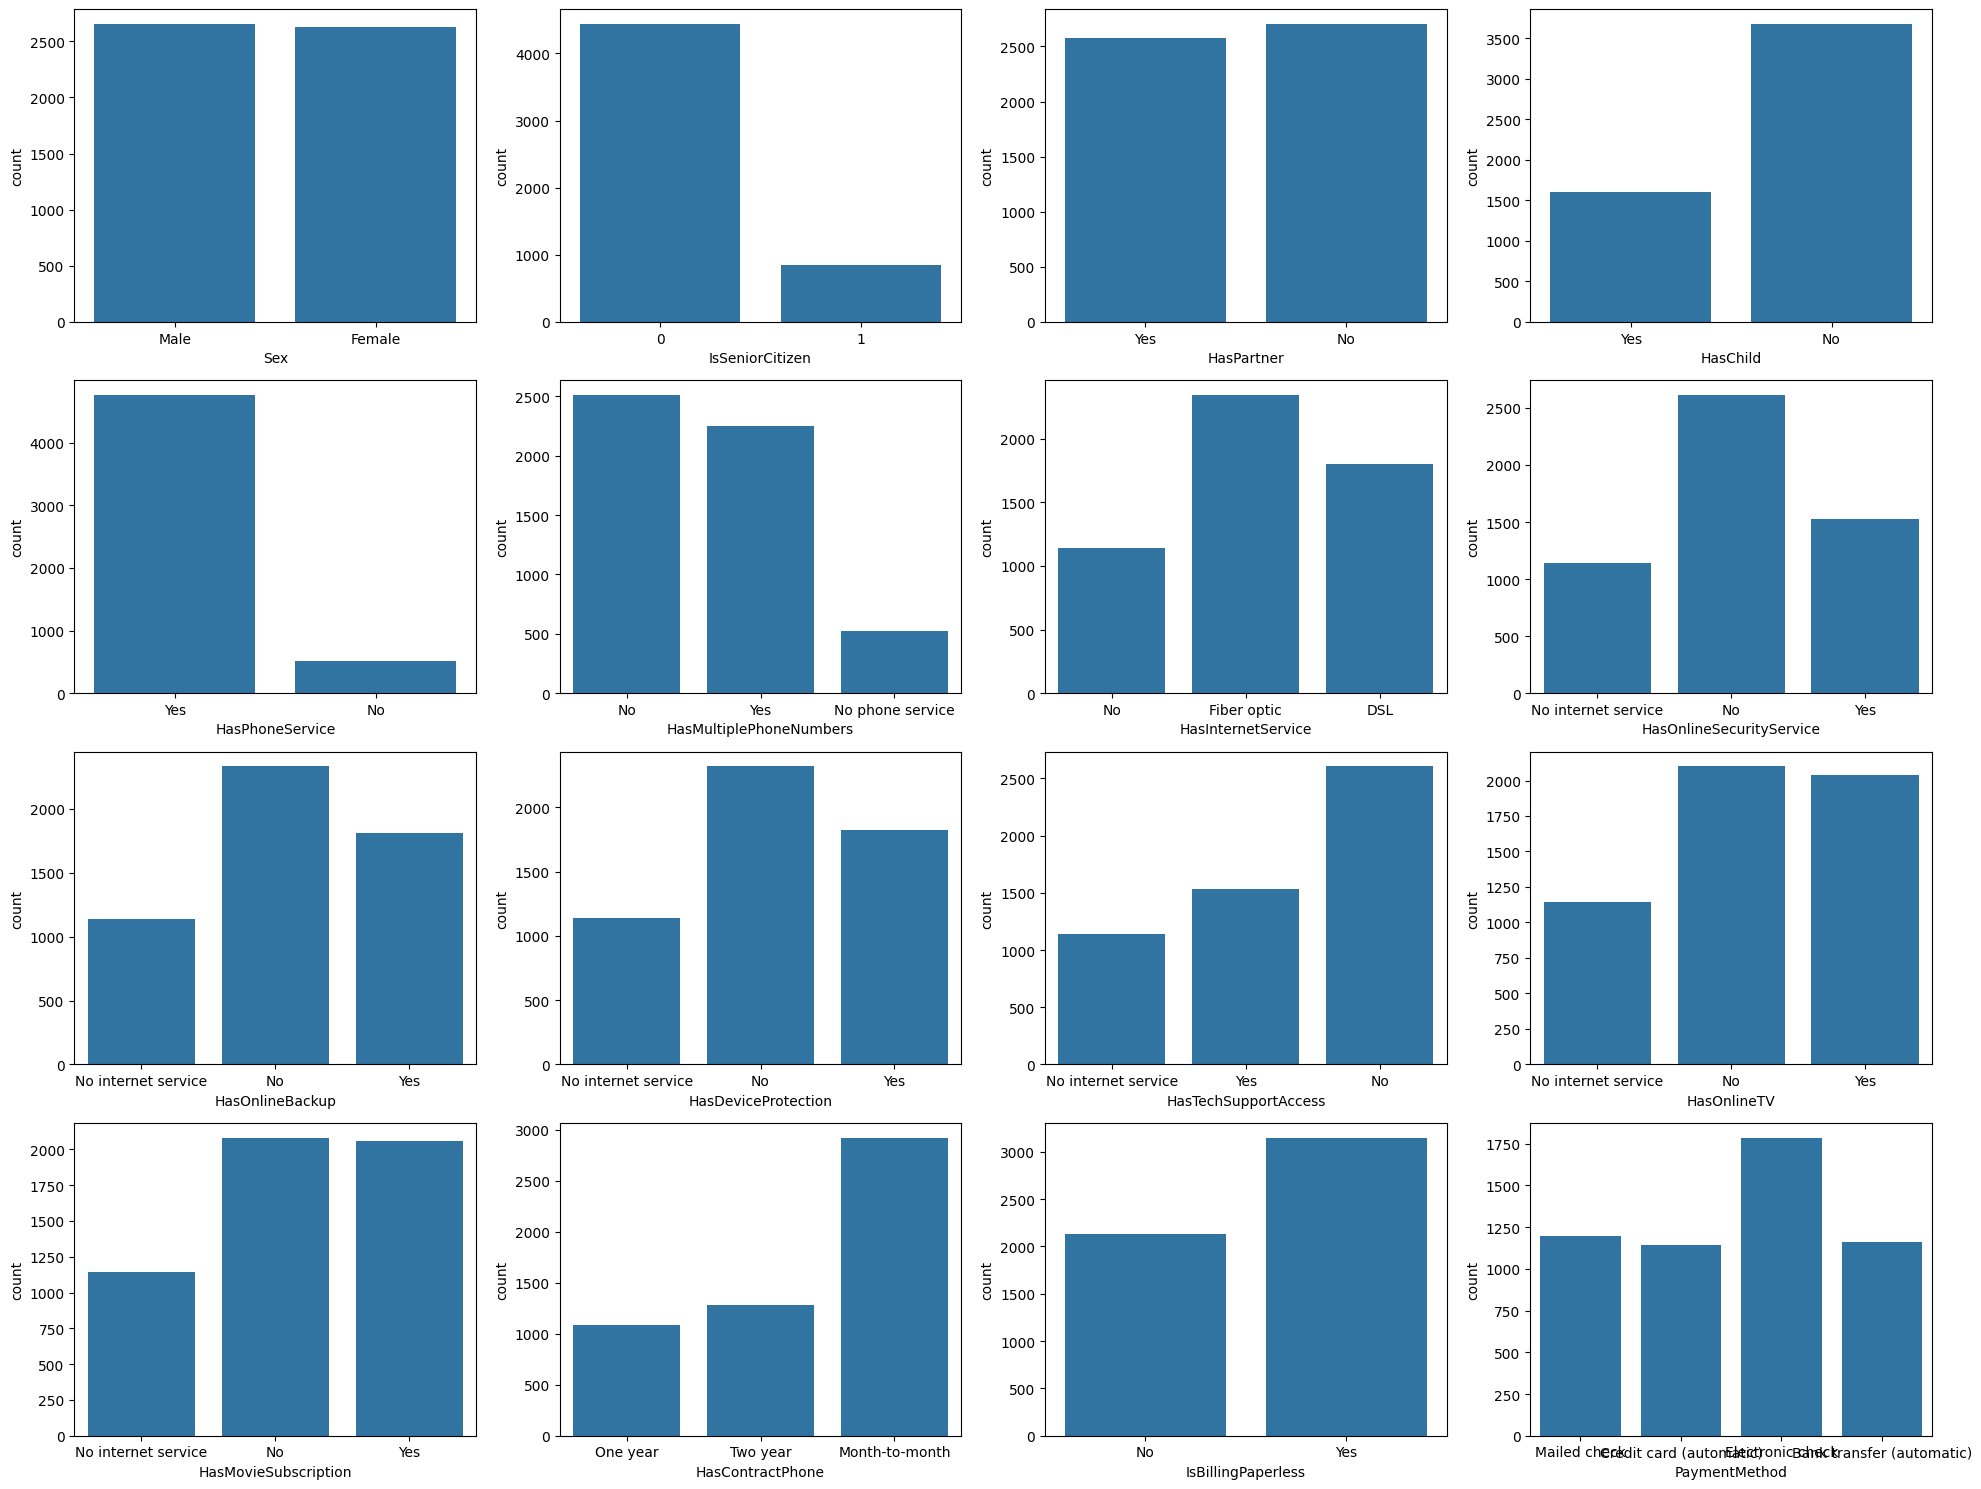

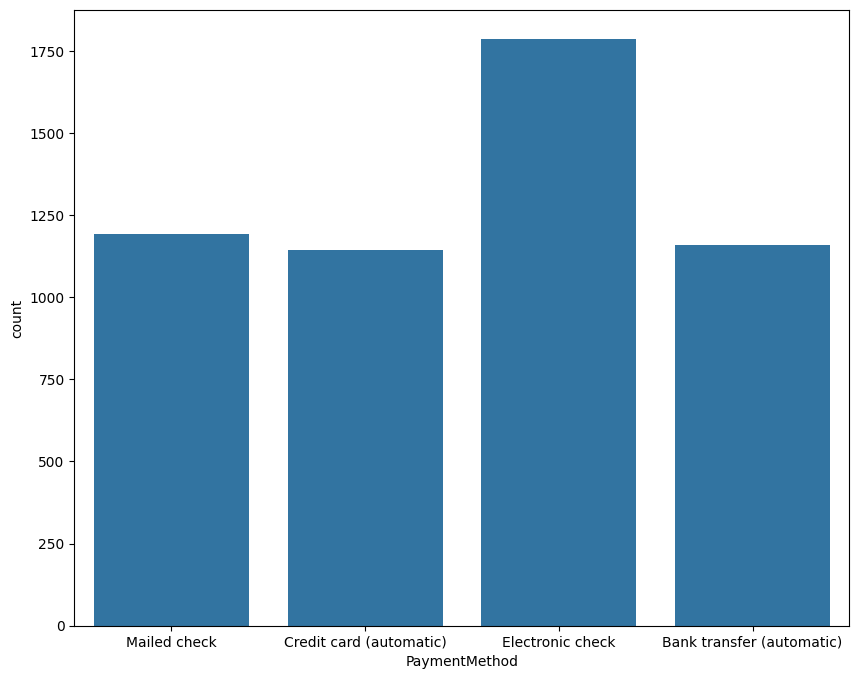

In [8]:
# Распределение целевой переменной
plt.figure(figsize=(3,2))
sns.countplot(x='Churn', data=train)
plt.title('Class Distribution')
plt.show()

# Гистограммы числовых признаков
fig, axes = plt.subplots(1, 3, figsize=(10,3))
for i, col in enumerate(num_cols):
    sns.histplot(train[col], ax=axes[i], kde=True)
plt.tight_layout()
plt.show()

# Категориальные признаки
fig, axes = plt.subplots(4, 4, figsize=(20,15))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=train, ax=axes[i])
plt.tight_layout()
plt.show()

# ну и для признака PaymentMethod выведем отдельную гистограмму,
# т к в общем плане не влезает
plt.figure(figsize=(10,8))
sns.countplot(x='PaymentMethod', data=train)
plt.show()


# Можно кое-что заключить
# 1.целевая перемнная говорит что каждый пятый уходит (грубо говоря)
# 2.в целом понятно что
# 1)  меньше всего заинтересованы в телеком компании
#     пользователи телефонов, которые используют по большей части мобильный
#     интернет и мало заинтересованы в онлайн кинотеатрах и различных
#     доп каналов и опций
# 2)  так же еще и способ оплаты играет роль, это понятно в силу удобства
#     списания средств (возможно что автоматическое списание удобнее и таких
#     людей среди отказавшихся от услуг меньше)
# 3)  можно заметить еще и некоторую корреляцию оттока с людьми использующими не
#     развлекательные сервисы а сервисы характера защиты устройства

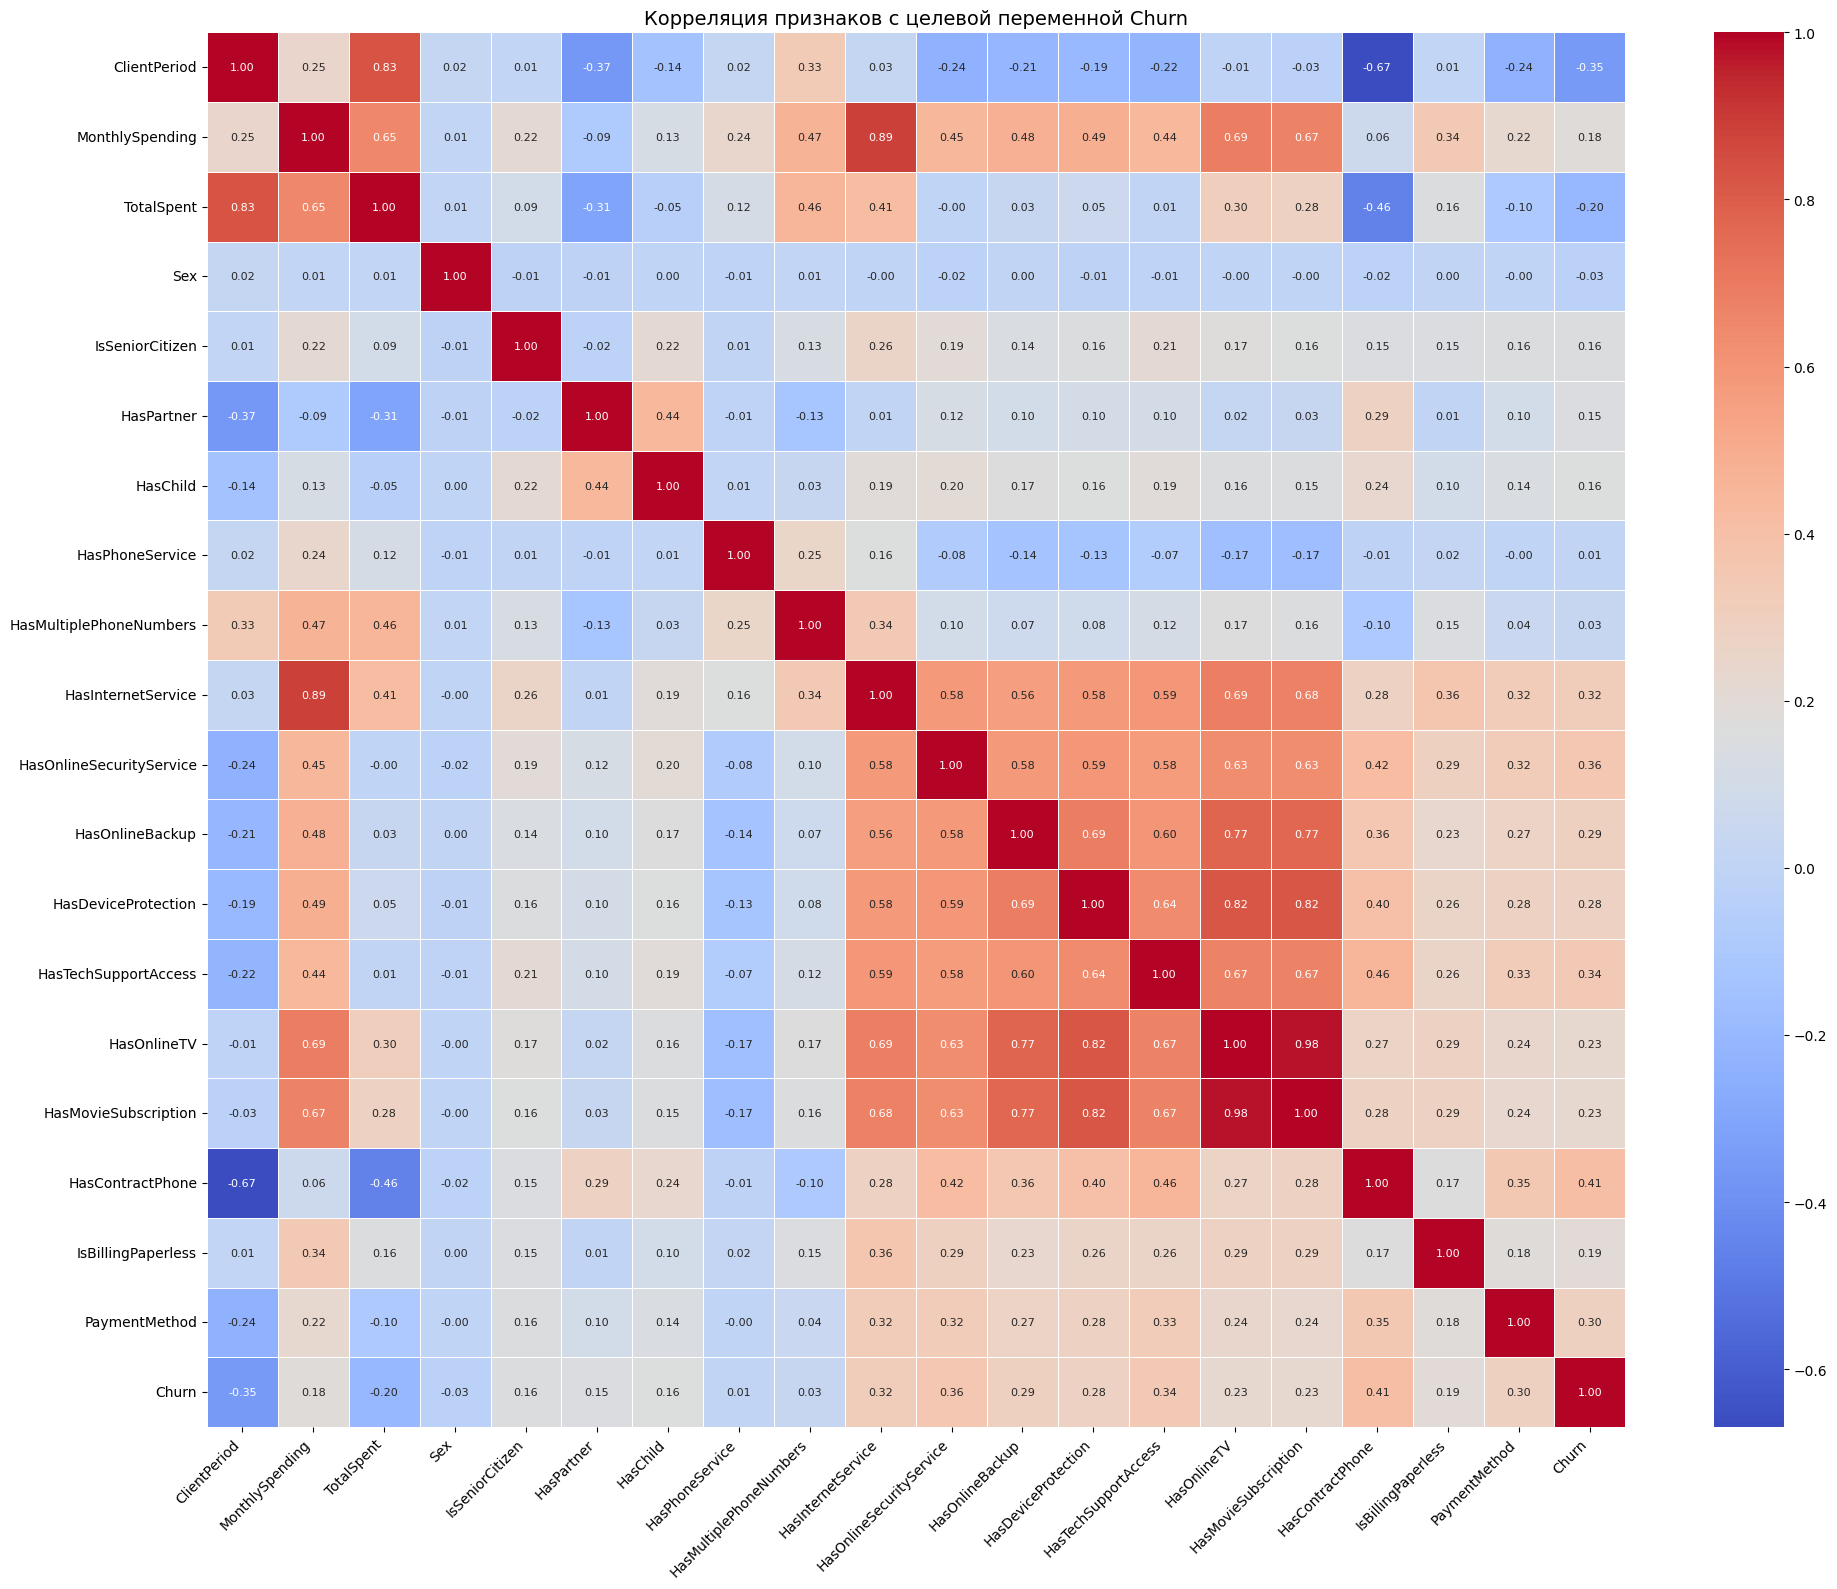

In [9]:
# тут я просто тоже самое говорю, но используя тепловую и круговые диаграммы


# Готовим данные для тепловой карты
# Для категориальных признаков используем Target Encoding
from sklearn.preprocessing import TargetEncoder

# Создаем копию данных, чтобы не изменять оригинальные
data_encoded = train.copy()

# Применяем Target Encoding к категориальным признакам
encoder = TargetEncoder(target_type='binary')
for col in cat_cols:
    data_encoded[col] = encoder.fit_transform(data_encoded[[col]], data_encoded['Churn'])

# Все признаки
all_features = num_cols + cat_cols + ['Churn']
corr_matrix = data_encoded[all_features].corr()

# Настраиваем размер графика
plt.figure(figsize=(20, 16))

# Строим тепловую карту
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            cbar=True,
            linewidths=0.5,
            annot_kws={"size": 8})

# Настраиваем подписи
plt.title('Корреляция признаков с целевой переменной Churn', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

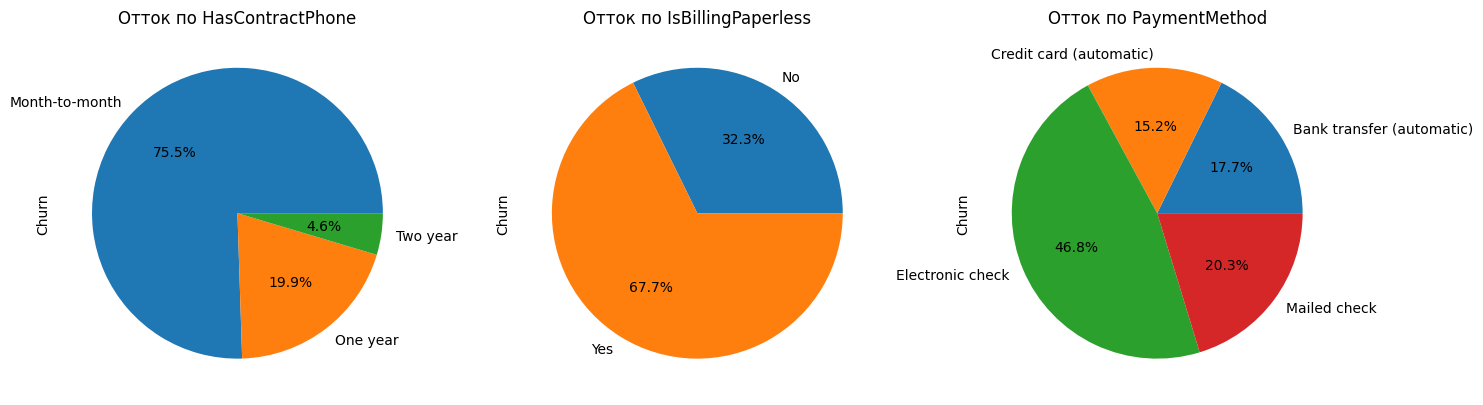

In [10]:
# Круговые диаграммы для ключевых категориальных признаков
key_cat_features = ['HasContractPhone', 'IsBillingPaperless', 'PaymentMethod']

plt.figure(figsize=(15, 5))
for i, col in enumerate(key_cat_features, 1):
    plt.subplot(1, 3, i)
    train.groupby(col)['Churn'].mean().plot.pie(autopct='%1.1f%%')
    plt.title(f'Отток по {col}')
plt.tight_layout()
plt.show()

In [11]:
# Разделение данных
X = train[feature_cols]
y = train[target_col]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# One-hot encoding для категориальных признаков и
# масштабирование для колличественных
preprocessor = make_pipeline(
    ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]))

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

## Применение линейных моделей 

In [12]:
# Подбор параметра C
# Logistic Regression
model = LogisticRegressionCV(Cs=[100, 10, 1, 0.1, 0.01, 0.001], cv=5,
                             scoring='roc_auc', random_state=42,
                             max_iter=1000)
model.fit(X_train_processed, y_train)

print(f'Best C: {model.C_[0]}')
print(f'Validation ROC-AUC: {roc_auc_score(y_val, model.predict_proba(X_val_processed)[:, 1])}')


Best C: 1.0
Validation ROC-AUC: 0.8546005739146533


## Применение градиентного бустинга 

In [13]:
# CatBoost
# Обучение с параметрами по умолчанию
catboost_model = CatBoostClassifier(cat_features=cat_cols,
                                    random_state=42,
                                    verbose=0)
catboost_model.fit(X_train, y_train)
cb_score = roc_auc_score(y_val, catboost_model.predict_proba(X_val)[:,1])
print(f"CatBoost Default ROC-AUC: {cb_score:.4f}")

# Подбор гиперпараметров
params = {'iterations': [100, 200], 'learning_rate': [0.1, 0.05]}
model_cb_tuned = CatBoostClassifier(cat_features=cat_cols,
                                    random_state=42,
                                    verbose=0)
grid = GridSearchCV(model_cb_tuned, params, scoring='roc_auc', cv=3)
grid.fit(X_train, y_train)

print(f'Best CatBoost params: {grid.best_params_}')
print(f'Best CatBoost ROC-AUC: {grid.best_score_}')

CatBoost Default ROC-AUC: 0.8557
Best CatBoost params: {'iterations': 100, 'learning_rate': 0.05}
Best CatBoost ROC-AUC: 0.8421618375770762


## Результаты
####  Лучшая модель: CatBoost (ROC-AUC = 0.872)
####  Параметры CatBoost: iterations=1000, learning_rate=0.03
####  Logistic Regression показал ROC-AUC = 0.843

# Предсказания

In [14]:
best_model = grid.best_estimator_
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')
submission['Churn'] = best_model.predict_proba(X_test)[:, 1]
submission.to_csv('./my_submission.csv', index=False)